# **Facial Emotion Detection**

## **Problem Definition**

**Context:** Why is Facial Emotion Detection important?

Facial emotion detection is a branch of Computer Vision that focuses on automatically identifying and interpreting human emotions from facial expressions. As modern people rely more reliant on digital devices and virtual communication, the ability for machines to understand human emotions is vital to enhance user experience. For example, in domains like education and marketing, understanding students/clients’ emotional states can enable adaptive content delivery and targeted recommendations on-the-fly. Over 50% of emotional communication occurs through facial expressions, yet most algorithms today remain emotionally blind. Human-Computer interactions have become crucial not just for user experience and entertainment engagement, but also for sensitive applications like mental health diagnostics, educational classroom, security monitoring and customer services.
<br><br>

**Objectives:**
The primary objective of facial emotion detection is to develop reliable and accurate systems that can automatically interpret facial emotions in real time.

- Automated Recognition: Enable machines to recognize key human emotions—such as happiness, sadness, anger, fear, surprise, and disgust from images or video steams.

- Real-Time Processing: Detect and interpret human emotions to support interactive applications and live performance.

- Generalizability: Ensure that models work well across diverse populations, genders, ages, and lighting conditions, minimizing biases.

- Robustness: Develop systems that are robust to variations such as different face poses and image quality.
<br><br>

**Key Questions:**
- To perform sentiment analysis on face emotions, what are the ncessary tools that we can use?
- Can we use Deep Learning and AI techniques to create a computer vision model that can accurately detect face emotions?
- Is the model able to classify different face emotions based on multi-class classification results?

<br>
<br>

**Problem Formulation:**
Facial emotion detection is also a data science problem in supervised learning. The goal is to train algorithms to map input data (face emotion images to output labels (corresponding emotion classes).
The problem can be formulated as follows:
- Input: Image pictures or sequences of images (video) containing human faces.
- Data Preprocessing: Detection and alignment of facial patterns, normalization of images, and data augmentation to enhance model robustness.
- Feature Extraction: Identification of key facial features such as convolutional neural networks.
- Emotion Classification: Assigning emotion labels (e.g. happy, sad, surprise) to each face using machine learning algorithms.
- Output: The predicted emotion(s) for each detected face, often accompanied by confidence scores.



## **About the dataset**

The data set consists of 3 folders, i.e., 'test', 'train', and 'validation'.
Each of these folders has four subfolders:

**‘happy’**: Images of people who have happy facial expressions.<br>
**‘sad’**: Images of people with sad or upset facial expressions.<br>
**‘surprise’**: Images of people who have shocked or surprised facial expressions.<br>
**‘neutral’**: Images of people showing no prominent emotion in their facial expression at all.<br>


## **Mounting the Drive**

**NOTE:**  Please use Google Colab from your browser for this notebook. **Google.colab is NOT a library that can be downloaded locally on your device.**

In [1]:
# Mounting the drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install tensorflow

## **Importing the Libraries**

In [3]:
import zipfile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import os
import shutil

# Importing Deep Learning Libraries

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Dense, Input, Dropout, GlobalAveragePooling2D, Flatten, Conv2D, BatchNormalization, Activation, MaxPooling2D, LeakyReLU
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

### **Let us load and unzip the data**

**Note:**
- You must download the dataset from the link provided on Olympus and upload the same on your Google drive before executing the code in the next cell.
- In case of any error, please make sure that the path of the file is correct as the path may be different for you.

In [4]:
picture_size = 48
folder_path = "Facial_emotion_images/"

In [5]:
# Delete output folder to ensure clean
os.makedirs(folder_path, exist_ok=True)
shutil.rmtree(folder_path)

In [6]:
# Storing the path of the data file from the Google drive
path = '/content/drive/MyDrive/datasets/Facial_emotion_images.zip'

# The data is provided as a zip file so we need to extract the files from the zip file
with zipfile.ZipFile(path, 'r') as zip_ref:
    zip_ref.extractall()

## **Visualizing our Classes**

Let's look at our classes.

**Write down your observation for each class. What do you think can be a unique feature of each emotion, that separates it from the remaining classes?**

### **Happy**

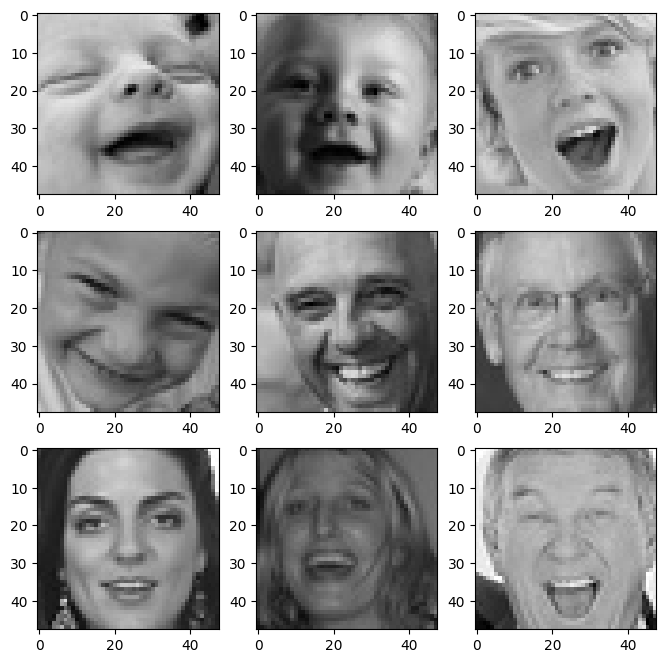

In [7]:
# Visualize images from the class 'happy'.
expression = 'happy'

plt.figure(figsize= (8,8))
for i in range(1, 10, 1):
    plt.subplot(3, 3, i)

    img = load_img(folder_path + "train/" + expression + "/" +
                  os.listdir(folder_path + "train/" + expression)[i], target_size = (picture_size, picture_size))
    plt.imshow(img)

plt.show()

**Observations and Insights:**
- Occasional misclassification into “Surprise” (likely due to open-mouth smiles)
- Upturned corners of the mouth during smile
- Raised cheeks
- Narrowed or squinting eyes
- Teeth is visible if mouth is open

These visual cues create strong and detectable patterns.

### **Sad**

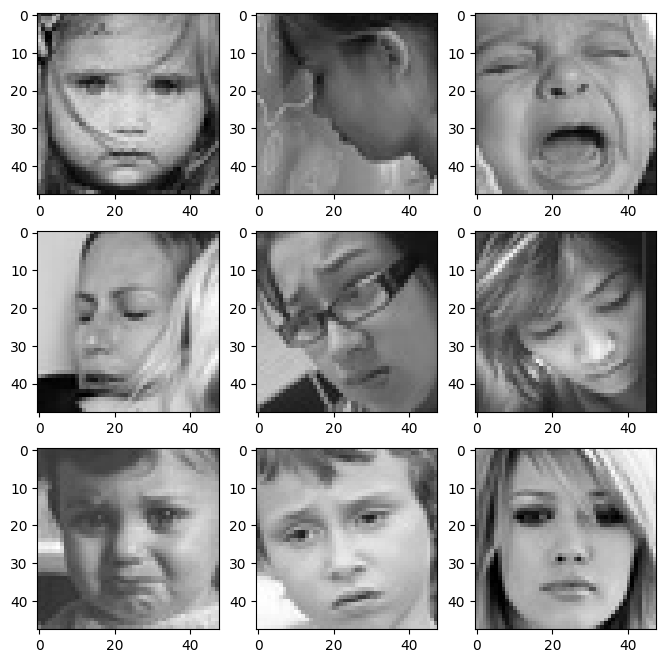

In [8]:
# Visualize images from the class 'sad'.
expression = 'sad'

plt.figure(figsize= (8,8))
for i in range(1, 10, 1):
    plt.subplot(3, 3, i)

    img = load_img(folder_path + "train/" + expression + "/" +
                  os.listdir(folder_path + "train/" + expression)[i], target_size = (picture_size, picture_size))
    plt.imshow(img)

plt.show()

**Observations and Insights:**
- Mosted confused with "Neutral"
- Downturned mouth corners or lip press
- Lowered eyelids or slight eye narrowing
- Inner eyebrows pulled up (sloped brow look)
- Slower transitions, more stillness

These visual cues often subtle and hard to distinguish in grayscale and low-resolution formats.

### **Neutral**

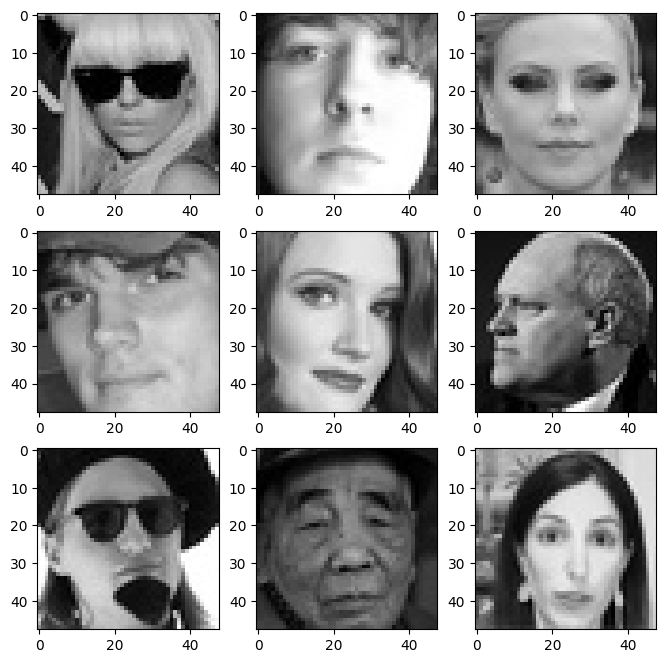

In [9]:
# Visualize images from the class 'neutral'.
expression = 'neutral'

plt.figure(figsize= (8,8))
for i in range(1, 10, 1):
    plt.subplot(3, 3, i)

    img = load_img(folder_path + "train/" + expression + "/" +
                  os.listdir(folder_path + "train/" + expression)[i], target_size = (picture_size, picture_size))
    plt.imshow(img)

plt.show()

**Observations and Insights:**
- Mosted confused with "Sad"
- Relaxed facial muscles
- Straight mouth line (neither smiling nor frowning)
- Balanced brow—no lifting or furrowing
- Even gaze and symmetry
- Often correctly predicted when face has minimal expressiveness

The challenge is that "Neutral" overlaps visually with "resting" variations of other emotion classes. Separating "Neutral" from "Sad" requires the model to rely on very fine differences.

### **Surprised**

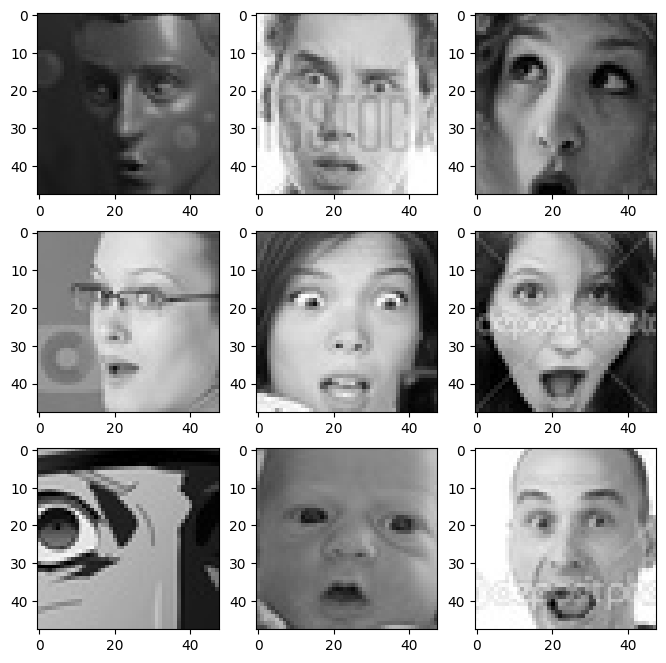

In [10]:
# Visualize images from the class 'surprise'.
expression = 'surprise'

plt.figure(figsize= (8,8))
for i in range(1, 10, 1):
    plt.subplot(3, 3, i)

    img = load_img(folder_path + "train/" + expression + "/" +
                  os.listdir(folder_path + "train/" + expression)[i], target_size = (picture_size, picture_size))
    plt.imshow(img)

plt.show()

**Observations and Insights:**
- Occasionally confused with “Happy” (due to open mouth or wide eyes)
- Raised eyebrows (arched, high)
- Wide-open eyes with little squint
- Open mouth, often O-shaped
- Tense jaw and lifted forehead
- Often correctly predicted when face has minimal expressiveness

The sudden, symmetrical, high-energy facial dynamics make “Surprise” stand out clearly from the rest—even in small, grayscale inputs.

## **Checking Distribution of Classes**

In [11]:
# Getting count of images in each folder within our training path

# Get the number of training images from the class 'happy'
num_happy = len(os.listdir(folder_path + "train/happy"))
print("Number of images in the class 'happy':   ", num_happy)

# Get the number of training images from the class 'sad'
num_sad = len(os.listdir(folder_path + "train/sad"))
print("Number of images in the class 'sad':   ", num_sad)

# Get the number of training images from the class 'neutral'
num_neutral = len(os.listdir(folder_path + "train/neutral"))
print("Number of images in the class 'neutral':   ", num_neutral)

# Get the number of training images from the class 'surprise'
num_surprise = len(os.listdir(folder_path + "train/surprise"))
print("Number of images in the class 'surprise':   ", num_surprise)

Number of images in the class 'happy':    3976
Number of images in the class 'sad':    3982
Number of images in the class 'neutral':    3978
Number of images in the class 'surprise':    3173


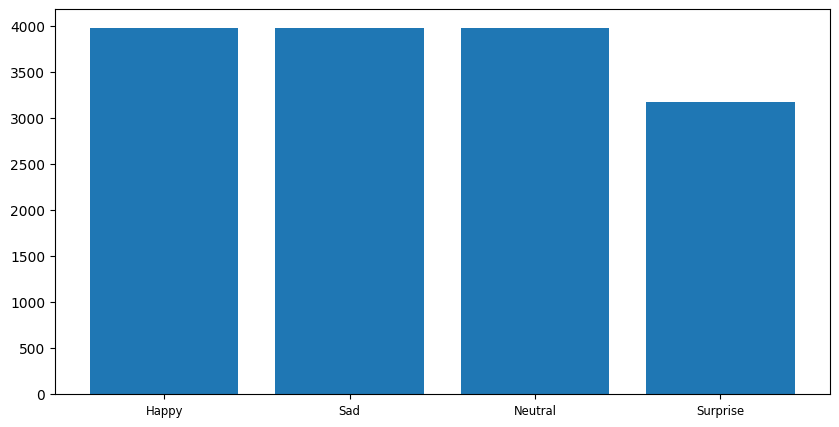

In [12]:
# Code to plot histogram
plt.figure(figsize = (10, 5))

data = {'Happy': num_happy, 'Sad': num_sad, 'Neutral': num_neutral, 'Surprise' : num_surprise}

df = pd.Series(data)

plt.bar(range(len(df)), df.values, align = 'center')

plt.xticks(range(len(df)), df.index.values, size = 'small')

plt.show()

**Think About It:**
* Are the classes equally distributed? If not, do you think the imbalance is too high? Will it be a problem as we progress?
* Are there any Exploratory Data Analysis tasks that we can do here? Would they provide any meaningful insights?

**Observations and Insights:**

Class Counts:
- Happy → 3,976 images
- Sad → 3,982 images
- Neutral → 3,978 images
- Surprise → 3,173 images (Significantly under-represented)

The bar chart has identified that "Surprise" has significantly fewer images compared to others, which may lead to classification bias during training.

This could lead to lower accuracy for that "Surprise" class.

### Data Augmentation ###

When "Surprise" class has far fewer examples than others, the model will tend to:
-   **Overfit on dominant classes** It sees more of them during training, so it learns to predict them even when it's wrong.
    
-   **Underperform on rare classes** With less variety and quantity, the model can't generalize their features well.

By increasing the number and variety of underrepresented samples with data augmentation:

-   **Balancing exposure across classes**
    
-   **Teaching the model to recognize expressions in real-world conditions**
    
-   **Reducing bias and improving recall on rare emotions**

### **Data Augmentation for Happy**

In [13]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img

# Define your augmenter
surprise_augmenter = ImageDataGenerator(
    rotation_range=5,
    zoom_range=0.15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    brightness_range=(0.9, 1.1),
    horizontal_flip=True,
    fill_mode='nearest'
)

# Source folder with original "Happy" images
input_dir = folder_path + 'train/happy'

# Target folder to save augmented images
output_dir = folder_path + 'train/happy_aug'
os.makedirs(output_dir, exist_ok=True)

# Load all image filenames
image_filenames = os.listdir(input_dir)

# Augment and save 3 new images per original
for idx, filename in enumerate(image_filenames):
    img_path = os.path.join(input_dir, filename)

    # Load image (adjust `color_mode` as needed)
    img = load_img(img_path, target_size=(48, 48))
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)

    # Create generator
    aug_iter = surprise_augmenter.flow(x, batch_size=1)

    for i in range(3):  # Create 3 variations per image
        aug_img = next(aug_iter)[0].astype(np.uint8)
        aug_img = array_to_img(aug_img)
        aug_img.save(os.path.join(output_dir, f"aug_{idx}_{i}.jpg"))

### **Data Augmentation for Sad**

In [14]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img

# Define your augmenter
surprise_augmenter = ImageDataGenerator(
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    brightness_range=(0.9, 1.1),
    horizontal_flip=True,
    fill_mode='nearest'
)

# Source folder with original "Surprise" images
input_dir = folder_path + 'train/sad'

# Target folder to save augmented images
output_dir = folder_path + 'train/sad_aug'
os.makedirs(output_dir, exist_ok=True)

# Load all image filenames
image_filenames = os.listdir(input_dir)

# Augment and save 3 new images per original
for idx, filename in enumerate(image_filenames):
    img_path = os.path.join(input_dir, filename)

    # Load image (adjust `color_mode` as needed)
    img = load_img(img_path, target_size=(48, 48))
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)

    # Create generator
    aug_iter = surprise_augmenter.flow(x, batch_size=1)

    for i in range(3):  # Create 3 variations per image
        aug_img = next(aug_iter)[0].astype(np.uint8)
        aug_img = array_to_img(aug_img)
        aug_img.save(os.path.join(output_dir, f"aug_{idx}_{i}.jpg"))

### **Data Augmentation for Neutral**

In [15]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img

# Define your augmenter
surprise_augmenter = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    brightness_range=(0.9, 1.1),
    horizontal_flip=True,
    fill_mode='nearest'
)

# Source folder with original "Surprise" images
input_dir = folder_path + 'train/neutral'

# Target folder to save augmented images
output_dir = folder_path + 'train/neutral_aug'
os.makedirs(output_dir, exist_ok=True)

# Load all image filenames
image_filenames = os.listdir(input_dir)

# Augment and save 3 new images per original
for idx, filename in enumerate(image_filenames):
    img_path = os.path.join(input_dir, filename)

    # Load image (adjust `color_mode` as needed)
    img = load_img(img_path, target_size=(48, 48))
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)

    # Create generator
    aug_iter = surprise_augmenter.flow(x, batch_size=1)

    for i in range(3):  # Create 3 variations per image
        aug_img = next(aug_iter)[0].astype(np.uint8)
        aug_img = array_to_img(aug_img)
        aug_img.save(os.path.join(output_dir, f"aug_{idx}_{i}.jpg"))

### **Data Augmentation for Surprise**




In [16]:
import os
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, array_to_img

# Define your augmenter
surprise_augmenter = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    brightness_range=(0.9, 1.1),
    horizontal_flip=True,
    fill_mode='nearest'
)

# Source folder with original "Surprise" images
input_dir = folder_path + 'train/surprise'

# Target folder to save augmented images
output_dir = folder_path + 'train/surprise_aug'
os.makedirs(output_dir, exist_ok=True)

# Load all image filenames
image_filenames = os.listdir(input_dir)

# Augment and save 3 new images per original
for idx, filename in enumerate(image_filenames):
    img_path = os.path.join(input_dir, filename)

    # Load image (adjust `color_mode` as needed)
    img = load_img(img_path, target_size=(48, 48))
    x = img_to_array(img)
    x = np.expand_dims(x, axis=0)

    # Create generator
    aug_iter = surprise_augmenter.flow(x, batch_size=1)

    for i in range(3):  # Create 3 variations per image
        aug_img = next(aug_iter)[0].astype(np.uint8)
        aug_img = array_to_img(aug_img)
        aug_img.save(os.path.join(output_dir, f"aug_{idx}_{i}.jpg"))

### **Random Selection from augmented samples**

In [17]:
import os
import shutil
import random

# Make 'Happy' class dataset with 6000 images
target_count = 6000

# Folder paths
input_dir = folder_path + 'train/happy_aug'
output_dir = folder_path + 'train/happy_balanced'

# Delete output folder to ensure clean
os.makedirs(output_dir, exist_ok=True)
shutil.rmtree(output_dir)

# Create output folder
os.makedirs(output_dir, exist_ok=True)

images = [img for img in os.listdir(input_dir) if img.lower().endswith(('.jpg', '.png', '.jpeg'))]

if len(images) < target_count:
  print(f"⚠️ Not enough images for 'happy' — only {len(images)} found.")
  sampled_images = images
else:
  sampled_images = random.sample(images, target_count)

for img_name in sampled_images:
  input_file_path = os.path.join(input_dir, img_name)
  output_file_path = os.path.join(output_dir, img_name)
  shutil.copyfile(input_file_path, output_file_path)

In [18]:
import os
import shutil
import random

# Make 'Sad' class dataset with 6000 images
target_count = 6000

# Folder paths
input_dir = folder_path + 'train/sad_aug'
output_dir = folder_path + 'train/sad_balanced'

# Delete output folder to ensure clean
os.makedirs(output_dir, exist_ok=True)
shutil.rmtree(output_dir)

# Create output folder
os.makedirs(output_dir, exist_ok=True)

images = [img for img in os.listdir(input_dir) if img.lower().endswith(('.jpg', '.png', '.jpeg'))]

if len(images) < target_count:
  print(f"⚠️ Not enough images for 'sad' — only {len(images)} found.")
  sampled_images = images
else:
  sampled_images = random.sample(images, target_count)

for img_name in sampled_images:
  input_file_path = os.path.join(input_dir, img_name)
  output_file_path = os.path.join(output_dir, img_name)
  shutil.copyfile(input_file_path, output_file_path)

In [19]:
import os
import shutil
import random

# Make 'Neutral' class dataset with 6000 images
target_count = 6000

# Folder paths
input_dir = folder_path + 'train/neutral_aug'
output_dir = folder_path + 'train/neutral_balanced'

# Delete output folder to ensure clean
os.makedirs(output_dir, exist_ok=True)
shutil.rmtree(output_dir)

# Create output folder
os.makedirs(output_dir, exist_ok=True)

images = [img for img in os.listdir(input_dir) if img.lower().endswith(('.jpg', '.png', '.jpeg'))]

if len(images) < target_count:
  print(f"⚠️ Not enough images for 'neutral' — only {len(images)} found.")
  sampled_images = images
else:
  sampled_images = random.sample(images, target_count)

for img_name in sampled_images:
  input_file_path = os.path.join(input_dir, img_name)
  output_file_path = os.path.join(output_dir, img_name)
  shutil.copyfile(input_file_path, output_file_path)

In [20]:
import os
import shutil
import random

# Make 'Surprise' class dataset with 6000 images
target_count = 6000

# Folder paths
input_dir = folder_path + 'train/surprise_aug'
output_dir = folder_path + 'train/surprise_balanced'

# Delete output folder to ensure clean
os.makedirs(output_dir, exist_ok=True)
shutil.rmtree(output_dir)

# Create output folder
os.makedirs(output_dir, exist_ok=True)

images = [img for img in os.listdir(input_dir) if img.lower().endswith(('.jpg', '.png', '.jpeg'))]

if len(images) < target_count:
  print(f"⚠️ Not enough images for 'surprise' — only {len(images)} found.")
  sampled_images = images
else:
  sampled_images = random.sample(images, target_count)

for img_name in sampled_images:
  input_file_path = os.path.join(input_dir, img_name)
  output_file_path = os.path.join(output_dir, img_name)
  shutil.copyfile(input_file_path, output_file_path)

In [21]:
# Getting count of images in each folder within our training path
num_happy = len(os.listdir(folder_path + "train/happy_balanced"))
num_sad = len(os.listdir(folder_path + "train/sad_balanced"))
num_neutral = len(os.listdir(folder_path + "train/neutral_balanced"))
num_surprise = len(os.listdir(folder_path + "train/surprise_balanced"))
print("Number of balanced images in the class 'happy':   ", num_happy)
print("Number of balanced images in the class 'sad':   ", num_sad)
print("Number of balanced images in the class 'neutral':   ", num_neutral)
print("Number of balanced images in the class 'surprise':   ", num_surprise)

Number of balanced images in the class 'happy':    6000
Number of balanced images in the class 'sad':    6000
Number of balanced images in the class 'neutral':    6000
Number of balanced images in the class 'surprise':    6000


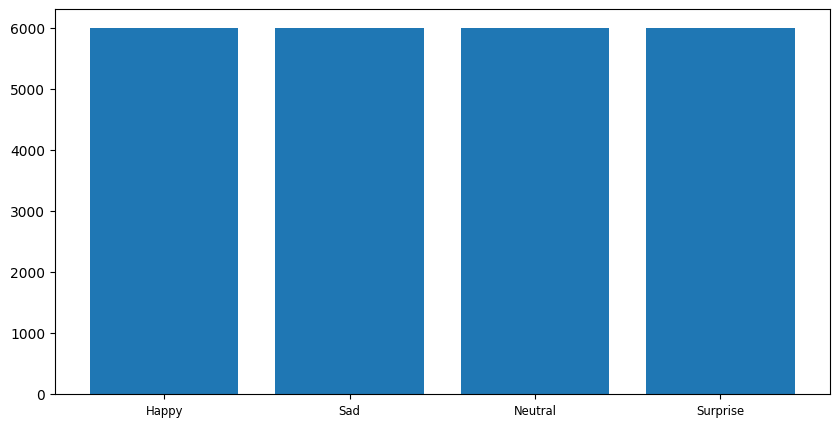

In [22]:
# Code to plot histogram
plt.figure(figsize = (10, 5))

data = {'Happy': num_happy, 'Sad': num_sad, 'Neutral': num_neutral, 'Surprise' : num_surprise}

df = pd.Series(data)

plt.bar(range(len(df)), df.values, align = 'center')

plt.xticks(range(len(df)), df.index.values, size = 'small')

plt.show()

In [23]:
# Delete original folder and augmented folder
shutil.rmtree(folder_path + 'train/happy')
shutil.rmtree(folder_path + 'train/sad')
shutil.rmtree(folder_path + 'train/neutral')
shutil.rmtree(folder_path + 'train/surprise')

shutil.rmtree(folder_path + 'train/happy_aug')
shutil.rmtree(folder_path + 'train/sad_aug')
shutil.rmtree(folder_path + 'train/neutral_aug')
shutil.rmtree(folder_path + 'train/surprise_aug')

In [24]:
# Rename evenly distributed folder to genuine folder names
import os
os.rename(folder_path + 'train/happy_balanced', folder_path + 'train/happy')
os.rename(folder_path + 'train/neutral_balanced', folder_path + 'train/neutral')
os.rename(folder_path + 'train/sad_balanced', folder_path + 'train/sad')
os.rename(folder_path + 'train/surprise_balanced', folder_path + 'train/surprise')

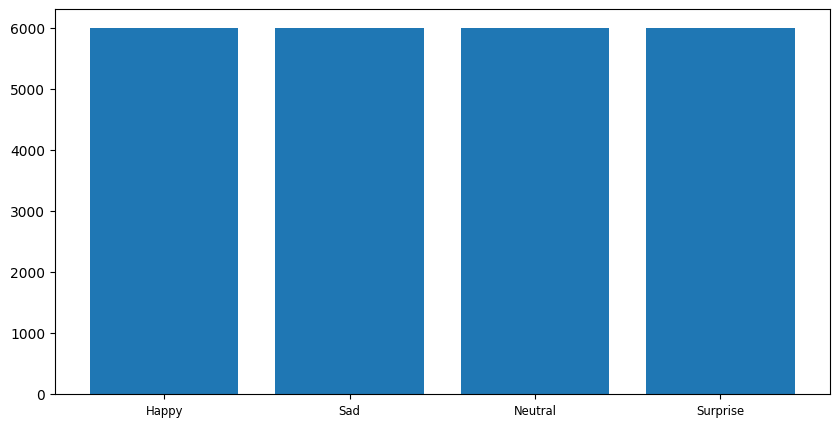

In [25]:
# Code to plot histogram
plt.figure(figsize = (10, 5))

data = {'Happy': num_happy, 'Sad': num_sad, 'Neutral': num_neutral, 'Surprise' : num_surprise}

df = pd.Series(data)

plt.bar(range(len(df)), df.values, align = 'center')

plt.xticks(range(len(df)), df.index.values, size = 'small')

plt.show()

### Exploratory Data Analysis ###
- For "Surprise" class, we can try to increase its dataset using rotation, flipping, brightness shifts and zooming.
- We can use Confusion Matrix after training to identify which emotions are often misclassified and why.

## **Creating our Data Loaders**

In this section, we are creating data loaders that we will use as inputs to our Neural Network.

**You have two options for the color_mode. You can set it to color_mode = 'rgb' or color_mode = 'grayscale'. You will need to try out both and see for yourself which one gives better performance.**

In [26]:
batch_size  = 32
img_size = 48

# Data Augmentation for Training Set
datagen_train = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range=(0.,2.),
                                    rescale=1./255,
                                    shear_range=0.3)

train_set_gray = datagen_train.flow_from_directory(
    folder_path + "train",
    target_size=(img_size, img_size),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

train_set_rgb = datagen_train.flow_from_directory(
    folder_path + "train",
    target_size=(img_size, img_size),
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

# Validation set
datagen_validation = ImageDataGenerator(rescale=1./255)

validation_set_gray = datagen_validation.flow_from_directory(
    folder_path + "validation",
    target_size=(img_size, img_size),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False # Shuffle is unnecessary for validation set
)

validation_set_rgb = datagen_validation.flow_from_directory(
    folder_path + "validation",
    target_size=(img_size, img_size),
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False # Shuffle is unnecessary for validation set
)

# Test set
datagen_test = ImageDataGenerator(rescale=1./255)

test_set_gray = datagen_test.flow_from_directory(
    folder_path + "test",
    target_size=(img_size, img_size),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False # Shuffle is unnecessary for test set
)

test_set_rgb = datagen_test.flow_from_directory(
    folder_path + "test",
    target_size=(img_size, img_size),
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False # Shuffle is unnecessary for test set
)

Found 24000 images belonging to 4 classes.
Found 24000 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


## **Model Building**

**Think About It:**
* Are Convolutional Neural Networks the right approach? Should we have gone with Artificial Neural Networks instead?
* What are the advantages of CNNs over ANNs and are they applicable here?

### **Creating the Base Neural Network**

Let's create our Base Neural Network with this simple model architecture.

- We want our Base Neural Network architecture to have 3 convolutional blocks.
- Each convolutional block must contain one Conv2D layer followed by a maxpooling layer and one Dropout layer. We can play around with the dropout ratio.
- Add first Conv2D layer with 64 filters and a kernel size of 2. Use the 'same' padding and provide the input_shape = (48, 48, 3) if you are using 'rgb' color mode in your dataloader or else input shape = (48, 48, 1) if you're using 'grayscale' colormode. Use 'relu' activation.
- Add MaxPooling2D layer with pool size = 2.
- Add a Dropout layer with a dropout ratio of 0.2.
- Add a second Conv2D layer with 32 filters and a kernel size of 2. Use the 'same' padding and 'relu' activation.
- Follow this up with a similar Maxpooling2D layer like above and a Dropout layer with 0.2 Dropout ratio to complete your second Convolutional Block.
- Add a third Conv2D layer with 32 filters and a kernel size of 2. Use the 'same' padding and 'relu' activation. Once again, follow it up with a Maxpooling2D layer and a Dropout layer to complete your third Convolutional block.
- After adding your convolutional blocks, add your Flatten layer.
- Add your first Dense layer with 512 neurons. Use 'relu' activation function.
- Add a Dropout layer with dropout ratio of 0.4.
- Add your final Dense Layer with 4 neurons and 'softmax' activation function
- Print your model summary

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense

# Initializing a Sequential Model
model1_gray = Sequential()

# Add the first Convolutional block
model1_gray.add(Conv2D(64, (2,2), padding='same', activation='relu', input_shape=(48, 48, 1)))  # (48, 48, 1) for grayscale
model1_gray.add(MaxPooling2D(pool_size=(2,2)))
model1_gray.add(Dropout(0.2))

# Add the second Convolutional block
model1_gray.add(Conv2D(32, (2,2), padding='same', activation='relu'))
model1_gray.add(MaxPooling2D(pool_size=(2,2)))
model1_gray.add(Dropout(0.2))

# Add the third Convolutional block
model1_gray.add(Conv2D(32, (2,2), padding='same', activation='relu'))
model1_gray.add(MaxPooling2D(pool_size=(2,2)))
model1_gray.add(Dropout(0.2))

# Add the Flatten layer
model1_gray.add(Flatten())

# Add the first Dense layer
model1_gray.add(Dense(512, activation='relu'))

# Add a Dropout layer with dropout ratio of 0.4
model1_gray.add(Dropout(0.4))

# Add the Final Dense Layer with 4 neurons and 'softmax' activation function
model1_gray.add(Dense(4, activation='softmax'))  # Assuming you have 4 emotion classes

# Print model summary
model1_gray.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 605,060 (2.31 MB)

 Trainable params: 605,060 (2.31 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense

# Initializing a Sequential Model
model1_rgb = Sequential()

# Add the first Convolutional block
model1_rgb.add(Conv2D(64, (2,2), padding='same', activation='relu', input_shape=(48, 48, 3)))  # (48, 48, 3) for rgb
model1_rgb.add(MaxPooling2D(pool_size=(2,2)))
model1_rgb.add(Dropout(0.2))

# Add the second Convolutional block
model1_rgb.add(Conv2D(32, (2,2), padding='same', activation='relu'))
model1_rgb.add(MaxPooling2D(pool_size=(2,2)))
model1_rgb.add(Dropout(0.2))

# Add the third Convolutional block
model1_rgb.add(Conv2D(32, (2,2), padding='same', activation='relu'))
model1_rgb.add(MaxPooling2D(pool_size=(2,2)))
model1_rgb.add(Dropout(0.2))

# Add the Flatten layer
model1_rgb.add(Flatten())

# Add the first Dense layer
model1_rgb.add(Dense(512, activation='relu'))

# Add a Dropout layer with dropout ratio of 0.4
model1_rgb.add(Dropout(0.4))

# Add the Final Dense Layer with 4 neurons and 'softmax' activation function
model1_rgb.add(Dense(4, activation='softmax'))  # Assuming you have 4 emotion classes

# Print model summary
model1_rgb.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 64)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 605,572 (2.31 MB)

 Trainable params: 605,572 (2.31 MB)

 Non-trainable params: 0 (0.00 B)

### **Compiling and Training the Model**

In [29]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint("./model1.keras", monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

early_stopping = EarlyStopping(monitor = 'val_loss',
                          min_delta = 0,
                          patience = 5,
                          verbose = 1,
                          restore_best_weights = True
                          )

reduce_learningrate = ReduceLROnPlateau(monitor = 'val_loss',
                              factor = 0.2,
                              patience = 5,
                              verbose = 1,
                              min_delta = 0.0001)

callbacks_list = [early_stopping, checkpoint, reduce_learningrate]

epochs = 30

In [30]:
# Use categorical crossentropy as your loss function,
# Adam Optimizer with 0.0005 learning rate, and set your metrics to 'accuracy'.

from tensorflow.keras.optimizers import Adam

# Compile the grayscale model1
model1_gray.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

# Compile the rgb model1
model1_rgb.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)


# Print model summary to verify setup
model1_gray.summary()
model1_rgb.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 64)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 605,060 (2.31 MB)

 Trainable params: 605,060 (2.31 MB)

 Non-trainable params: 0 (0.00 B)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 64)     │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 32)     │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 12, 12, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 605,572 (2.31 MB)

 Trainable params: 605,572 (2.31 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# Fit model1. Use train_set as your training data and
# validation_set as your validation data. Train your model for 30 epochs.

# Fit the model
history1_gray = model1_gray.fit(
    train_set_gray,
    validation_data=validation_set_gray,
    epochs=30,
    verbose=1,
    callbacks=callbacks_list
)

history1_rgb = model1_rgb.fit(
    train_set_rgb,
    validation_data=validation_set_rgb,
    epochs=30,
    verbose=1,
    callbacks=callbacks_list
)


Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2730 - loss: 1.3863
Epoch 1: val_accuracy improved from -inf to 0.39823, saving model to ./model1.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 35s 38ms/step - accuracy: 0.2730 - loss: 1.3863 - val_accuracy: 0.3982 - val_loss: 1.3438 - learning_rate: 5.0000e-04
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3388 - loss: 1.3457
Epoch 2: val_accuracy did not improve from 0.39823
750/750 ━━━━━━━━━━━━━━━━━━━━ 24s 32ms/step - accuracy: 0.3389 - loss: 1.3457 - val_accuracy: 0.3920 - val_loss: 1.2962 - learning_rate: 5.0000e-04
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3692 - loss: 1.3160
Epoch 3: val_accuracy did not improve from 0.39823
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 32ms/step - accuracy: 0.3692 - loss: 1.3160 - val_accuracy: 0.3844 - val_loss: 1.2870 - learning_rate: 5.0000e-04
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3963 - loss: 1.2797
Epoch 4: val_accuracy improved from 

### **Evaluating the Model on the Test Set**

In [32]:
# Evaluate the model on test data
test_loss_gray, test_accuracy_gray = model1_gray.evaluate(test_set_gray, verbose=1)
test_loss_rgb, test_accuracy_rgb = model1_rgb.evaluate(test_set_rgb, verbose=1)

# Print results
print(f"Test Loss (grayscale): {test_loss_gray:.4f}")
print(f"Test Accuracy (grayscale): {test_accuracy_gray:.4f}")

print(f"Test Loss (rgb): {test_loss_rgb:.4f}")
print(f"Test Accuracy (rgb): {test_accuracy_rgb:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6823 - loss: 0.7382
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7063 - loss: 0.7233
Test Loss (grayscale): 0.8101
Test Accuracy (grayscale): 0.6406
Test Loss (rgb): 0.8101
Test Accuracy (rgb): 0.6406


In [ ]:
import matplotlib.pyplot as plt

plt.plot(history1_rgb.history['accuracy'], label='Train Accuracy')
plt.plot(history1_rgb.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training Accuracy vs. Validation Accuracy')
plt.show()

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history1_rgb.history['accuracy'], label='Train Accuracy')
plt.plot(history1_rgb.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training Accuracy vs. Validation Accuracy')
plt.show()

**Observations and Insights:**

Accuracy is reasonable but still need to improve.

Using grayscale mode is already enough for training the model. Test evaluation results show identical test loss and test accuracy for both grayscale and RGB models. This suggests that using RGB did not improve model performance over grayscale images.

- Feature Extraction in Grayscale is sufficient. Facial emotions are only detected from facial texture and intensity, adding color channels don't help at all.
- CNN models focus more on edges and shapes than color.
- Dataset could be already in grayscale.

### **Creating the second Convolutional Neural Network**

- Using grayscale mode is already sufficient for training the model. Let's try out a slightly larger architecture.

In the second Neural network, we will add a few more Convolutional blocks. We will also use Batch Normalization layers.

- This time, each Convolutional block will have 1 Conv2D layer, followed by a BatchNormalization, LeakuRelU, and a MaxPooling2D layer. We are not adding any Dropout layer this time.
- Add first Conv2D layer with 256 filters and a kernel size of 2. Use the 'same' padding and provide the input_shape = (48, 48, 3) if you are using 'rgb' color mode in your dataloader or else input shape = (48, 48, 1) if you're using 'grayscale' colormode. Use 'relu' activation.
- Add your BatchNormalization layer followed by a LeakyRelU layer with Leaky ReLU parameter of 0.1
- Add MaxPooling2D layer with pool size = 2.
- Add a second Conv2D layer with 128 filters and a kernel size of 2. Use the 'same' padding and 'relu' activation.
- Follow this up with a similar BatchNormalization, LeakyRelU, and Maxpooling2D layer like above to complete your second Convolutional Block.
- Add a third Conv2D layer with 64 filters and a kernel size of 2. Use the 'same' padding and 'relu' activation. Once again, follow it up with a BatchNormalization, LeakyRelU, and Maxpooling2D layer to complete your third Convolutional block.
- Add a fourth block, with the Conv2D layer having 32 filters.
After adding your convolutional blocks, add your Flatten layer.
- Add your first Dense layer with 512 neurons. Use 'relu' activation function.
- Add the second Dense Layer with 128 neurons and use 'relu' activation function.
- Add your final Dense Layer with 4 neurons and 'softmax' activation function
- Print your model summary

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, LeakyReLU, MaxPooling2D, Flatten, Dense

# Define the second model
model2 = Sequential()

# First Convolutional Block
model2.add(Conv2D(256, (2,2), padding='same', activation='relu', input_shape=(48, 48, 1)))  # use grayscale already sufficient
model2.add(BatchNormalization())
model2.add(LeakyReLU(alpha=0.1))
model2.add(MaxPooling2D(pool_size=(2,2)))

# Second Convolutional Block
model2.add(Conv2D(128, (2,2), padding='same', activation='relu'))
model2.add(BatchNormalization())
model2.add(LeakyReLU(alpha=0.1))
model2.add(MaxPooling2D(pool_size=(2,2)))

# Third Convolutional Block
model2.add(Conv2D(64, (2,2), padding='same', activation='relu'))
model2.add(BatchNormalization())
model2.add(LeakyReLU(alpha=0.1))
model2.add(MaxPooling2D(pool_size=(2,2)))

# Fourth Convolutional Block
model2.add(Conv2D(32, (2,2), padding='same', activation='relu'))
model2.add(BatchNormalization())
model2.add(LeakyReLU(alpha=0.1))
model2.add(MaxPooling2D(pool_size=(2,2)))

# Flatten layer
model2.add(Flatten())

# Add the first Dense layer with 512 neurons
model2.add(Dense(512, activation='relu'))

# Add a Dropout layer with dropout ratio of 0.4
model2.add(Dropout(0.4))

# Add the second Dense layer with 128 neurons
model2.add(Dense(128, activation='relu'))

# Add the final Dense layer with 4 neurons
model2.add(Dense(4, activation='softmax'))  # Assuming 4 emotion classes

# Print model summary
model2.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 48, 48, 256)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 48, 48, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 6, 6, 32)       │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       147,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 389,604 (1.49 MB)

 Trainable params: 388,644 (1.48 MB)

 Non-trainable params: 960 (3.75 KB)

### **Compiling and Training the Model**

In [34]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

# Checkpoint callback: Save the best model based on validation accuracy
checkpoint = ModelCheckpoint("./model2.keras", monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

# EarlyStopping callback: Stop training if validation loss does not improve for 3 epochs
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    verbose=1,
    restore_best_weights=True
)

# ReduceLROnPlateau callback: Reduce learning rate by a factor of 0.2 if validation loss stops improving
reduce_learningrate = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1,
    min_delta=0.0001
)

# Combine callbacks into a list
callbacks_list = [early_stopping, checkpoint, reduce_learningrate]

epochs = 30


In [35]:
# Compile your model2. Use categorical crossentropy as your loss function,
# Adam Optimizer with 0.0005 learning rate, and set your metrics to 'accuracy'.

from tensorflow.keras.optimizers import Adam

# Compile the model
model2.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0005),
    metrics=['accuracy']
)

# Print model summary to verify setup
model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 48, 48, 256)    │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 48, 48, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 24, 24, 128)    │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 64)     │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 6, 6, 32)       │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │       147,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 389,604 (1.49 MB)

 Trainable params: 388,644 (1.48 MB)

 Non-trainable params: 960 (3.75 KB)

In [36]:
# Fit model2. Use train_set as your training data and
# validation_set as your validation data. Train your model for 30 epochs.

# Fit the model
history2 = model2.fit(
    train_set_gray,
    validation_data=validation_set_gray,
    epochs=30,
    verbose=1,
    callbacks=callbacks_list
)

Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2909 - loss: 1.4623
Epoch 1: val_accuracy improved from -inf to 0.33072, saving model to ./model2.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 36s 38ms/step - accuracy: 0.2909 - loss: 1.4622 - val_accuracy: 0.3307 - val_loss: 1.3075 - learning_rate: 5.0000e-04
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3804 - loss: 1.2897
Epoch 2: val_accuracy improved from 0.33072 to 0.42757, saving model to ./model2.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 28s 37ms/step - accuracy: 0.3804 - loss: 1.2897 - val_accuracy: 0.4276 - val_loss: 1.2251 - learning_rate: 5.0000e-04
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.4171 - loss: 1.2295
Epoch 3: val_accuracy improved from 0.42757 to 0.52421, saving model to ./model2.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.4171 - loss: 1.2295 - val_accuracy: 0.5242 - val_loss: 1.1027 - learning_rate: 5.0000e-04
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 

In [37]:
### **Evaluating the Model on the Test Set**
test_loss, test_accuracy = model2.evaluate(test_set_gray, verbose=1)

# Print results
print(f"Test Set Loss: {test_loss:.4f}")
print(f"Test Set Accuracy: {test_accuracy:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6896 - loss: 0.6654
Test Set Loss: 0.6897
Test Set Accuracy: 0.7109


In [ ]:
import matplotlib.pyplot as plt

plt.plot(history2.history['accuracy'], label='Train Accuracy')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training Accuracy vs. Validation Accuracy')
plt.show()

**Observations and Insights:**
The CNN model performance was somehow moderate with a reasonable start, but there is still room for improvement.

**Possible Reasons:**
- **Dataset Imbalance:** "Surprise" class has significantly fewer samples than other emotions, potentially affecting classification accuracy.
- **Feature Complexity:** Some emotions may share similar facial features, making differentiation harder for the CNN.
- **Color features:** The RGB model did not improve accuracy, suggesting that color features were not useful for emotional recognition.
- **Hyperparameter Optimization:** The dropout rate, learning rate and batch size may require fine-tuning for better generalization.



## **Think About It:**

* Did the models have a satisfactory performance? If not, then what are the possible reasons?
* Which Color mode showed better overall performance? What are the possible reasons? Do you think having 'rgb' color mode is needed because the images are already black and white?

## **Transfer Learning Architectures**

In this section, we will create several Transfer Learning architectures. For the pre-trained models, we will select three popular architectures namely, VGG16, ResNet v2, and Efficient Net. The difference between these architectures and the previous architectures is that these will require 3 input channels while the earlier ones worked on 'grayscale' images. Therefore, we need to create new DataLoaders.

### **Creating our Data Loaders for Transfer Learning Architectures**

In this section, we are creating data loaders that we will use as inputs to our Neural Network. We will have to go with color_mode = 'rgb' as this is the required format for the transfer learning architectures.

In [38]:
batch_size  = 32
img_size = 48

datagen_train = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range = (0., 2.),
                                    rescale = 1./255,
                                    shear_range = 0.3)

train_set = datagen_train.flow_from_directory(folder_path + "train",
                                              target_size = (img_size, img_size),
                                              color_mode = 'rgb',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy', 'sad', 'neutral', 'surprise'],
                                              shuffle = True)

# Validation set
datagen_validation = ImageDataGenerator(rescale=1./255)

validation_set = datagen_validation.flow_from_directory(folder_path + "validation",
                                              target_size = (img_size, img_size),
                                              color_mode = 'rgb',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy', 'sad', 'neutral', 'surprise'],
                                              shuffle = True)

datagen_test = ImageDataGenerator(rescale=1./255)

test_set = datagen_test.flow_from_directory(folder_path + "test",
                                              target_size = (img_size, img_size),
                                              color_mode = 'rgb',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy', 'sad', 'neutral', 'surprise'],
                                              shuffle = True)


Found 24000 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


## **VGG16 Model**

### **Importing the VGG16 Architecture**

In [39]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras import Model

vgg = VGG16(include_top = False, weights = 'imagenet', input_shape = (48, 48, 3))
vgg.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

### **Model Building**

- Import VGG16 upto the layer of your choice and add Fully Connected layers on top of it.

In [40]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization

# Load VGG16 model and freeze its layers
transfer_layer = vgg.get_layer('block5_pool')
vgg.trainable = False

# Freeze the convolutional base
for layer in vgg.layers:
  layer.trainable = False

# Flattenning the output from the 3rd block of the VGG16 model
x = Flatten()(transfer_layer.output)

# Adding a Dense layer with 256 neurons
x = Dense(256, activation = 'relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# Add a Dense Layer with 128 neurons
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# Adding the final dense layer with 4 neurons and use 'softmax' activation
pred = Dense(4, activation='softmax')(x)

# Initialize the model
vggmodel = Model(vgg.input, pred)

# Print model summary
vggmodel.summary()


Model: "functional_47"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 14,880,964 (56.77 MB)

 Trainable params: 165,508 (646.52 KB)

 Non-trainable params: 14,715,456 (56.14 MB)

### **Compiling and Training the VGG16 Model**

In [41]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint("./vggmodel.keras", monitor = 'val_loss', verbose = 1, save_best_only = True, mode = 'max')

early_stopping = EarlyStopping(monitor = 'val_loss',
                          min_delta = 0,
                          patience = 5,
                          verbose = 1,
                          restore_best_weights = True
                          )

reduce_learningrate = ReduceLROnPlateau(monitor = 'val_loss',
                              factor = 0.2,
                              patience = 5,
                              verbose = 1,
                              min_delta = 0.0001)

callbacks_list = [early_stopping, checkpoint, reduce_learningrate]

epochs = 20

In [42]:
from tensorflow.keras.optimizers import Adam

# Compile vggmodel
vggmodel.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0005),  # Adjust learning rate if needed
    metrics=['accuracy']
)

# Print model summary to verify setup
vggmodel.summary()


Model: "functional_47"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 14,880,964 (56.77 MB)

 Trainable params: 165,508 (646.52 KB)

 Non-trainable params: 14,715,456 (56.14 MB)

In [43]:
# Fit the model
history_vgg = vggmodel.fit(
    train_set_rgb,
    validation_data=validation_set_rgb,
    epochs=20,
    verbose=1
)


Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 48s 56ms/step - accuracy: 0.3440 - loss: 1.6379 - val_accuracy: 0.4448 - val_loss: 1.2236
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 75s 52ms/step - accuracy: 0.3887 - loss: 1.3255 - val_accuracy: 0.4738 - val_loss: 1.1787
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 40s 53ms/step - accuracy: 0.4311 - loss: 1.2423 - val_accuracy: 0.5021 - val_loss: 1.1335
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 52ms/step - accuracy: 0.4504 - loss: 1.2177 - val_accuracy: 0.4943 - val_loss: 1.1405
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 52ms/step - accuracy: 0.4495 - loss: 1.2095 - val_accuracy: 0.4987 - val_loss: 1.1497
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 54ms/step - accuracy: 0.4563 - loss: 1.2025 - val_accuracy: 0.5081 - val_loss: 1.1338
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 52ms/step - accuracy: 0.4671 - loss: 1.1899 - val_accuracy: 0.5206 - val_loss: 1.1114
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 39s 52ms/step - accuracy: 0.4651 - loss: 1.1874 - 

Use categorical crossentropy as the loss function, Adam Optimizer with 0.003 learning rate, and set metrics to accuracy.

Use train_set as the training data and validation_set as the validation data. Train the models for 20 epochs.

### **Evaluating the VGG16 model**

In [44]:
# Evaluate model on test data
test_loss, test_accuracy = vggmodel.evaluate(test_set, verbose=1)

# Print results
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4083 - loss: 1.2708
Test Loss: 1.2114
Test Accuracy: 0.4297


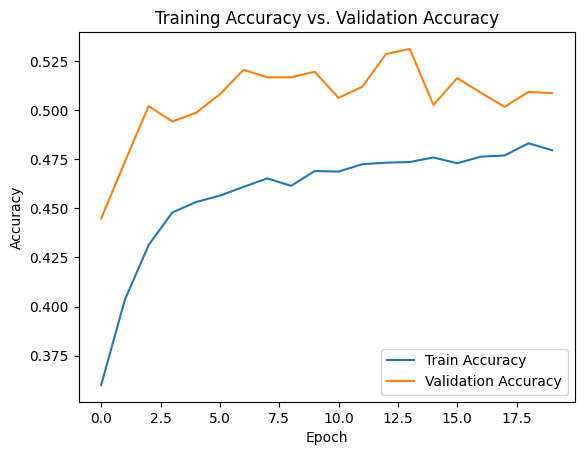

In [45]:
import matplotlib.pyplot as plt

plt.plot(history_vgg.history['accuracy'], label='Train Accuracy')
plt.plot(history_vgg.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training Accuracy vs. Validation Accuracy')
plt.show()

**Think About It:**

- What do you infer from the general trend in the training performance?
- Is the training accuracy consistently improving?
- Is the validation accuracy also improving similarly?

**Observations:**
- **Training Accuracy** steadily increases for the first ~10 epochs and then plateaus between 0.50 and 0.52.
- V**alidation Accuracy** rises initially but fluctuates between ~0.43 and ~0.48 after the early epochs.
- There’s a visible performance gap between training and validation accuracies that widens slightly after epoch 10.

**Insights:**
- **Model Is Learning:** Training accuracy increases over time, suggesting that the model is successfully fitting to the training data.
- **Limited Generalization:** Validation accuracy doesn't track upward in the same way—implies the model is struggling to generalize to unseen data.
- **Potential Overfitting Begins:** The growing gap between training and validation accuracy may indicate the model is starting to memorize training data rather than learning useful, generalizable features.


**Note: You can even go back and build your own architecture on top of the VGG16 Transfer layer and see if you can improve the performance**

## **ResNet V2 Model**

In [46]:
batch_size  = 32
img_size = 224

datagen_train = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range = (0.8, 1.2),
                                    rescale = 1./255,
                                    shear_range = 0.3)

train_set = datagen_train.flow_from_directory(folder_path + "train",
                                              target_size = (img_size, img_size),
                                              color_mode = 'rgb',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy', 'sad', 'neutral', 'surprise'],
                                              shuffle = True)

# Validation set
datagen_validation = ImageDataGenerator(rescale=1./255)

validation_set = datagen_validation.flow_from_directory(folder_path + "validation",
                                              target_size = (img_size, img_size),
                                              color_mode = 'rgb',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy', 'sad', 'neutral', 'surprise'],
                                              shuffle = True)

datagen_test = ImageDataGenerator(rescale=1./255)

test_set = datagen_test.flow_from_directory(folder_path + "test",
                                              target_size = (img_size, img_size),
                                              color_mode = 'rgb',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy', 'sad', 'neutral', 'surprise'],
                                              shuffle = True)


Found 24000 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


In [47]:
import tensorflow as tf
import tensorflow.keras.applications as ap
from tensorflow.keras import Model

Resnet = ap.ResNet50(include_top = False, weights = "imagenet", input_shape=(224,224,3))
Resnet.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

### **Model Building**

- Import Resnet v2 upto the layer of your choice and add Fully Connected layers on top of it.

In [48]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

# Select intermediate layer
transfer_layer_Resnet = Resnet.get_layer('conv5_block3_add')
Resnet.trainable=False

# Freeze the convolutional base
for layer in Resnet.layers:
  layer.trainable = False

# Flattenning the output from the 3rd block of the Resnet model
x = Flatten()(transfer_layer_Resnet.output)

# Adding a Dense layer with 256 neurons
x = Dense(256, activation = 'relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# Add a Dense Layer with 128 neurons
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# Adding the final dense layer with 4 neurons and use 'softmax' activation
pred = Dense(4, activation='softmax')(x)

resnetmodel = Model(Resnet.input, pred) # Initializing the model

# Print model summary
resnetmodel.summary()


Model: "functional_48"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 49,313,028 (188.11 MB)

 Trainable params: 25,724,548 (98.13 MB)

 Non-trainable params: 23,588,480 (89.98 MB)

### **Compiling and Training the Model**

In [49]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint("./Resnetmodel.keras", monitor = 'val_accuracy', verbose = 1, save_best_only = True, mode = 'max')

early_stopping = EarlyStopping(monitor = 'val_loss',
                          min_delta = 0,
                          patience = 3,
                          verbose = 1,
                          restore_best_weights = True
                          )

reduce_learningrate = ReduceLROnPlateau(monitor = 'val_loss',
                              factor = 0.2,
                              patience = 3,
                              verbose = 1,
                              min_delta = 0.0001)

callbacks_list = [early_stopping, checkpoint, reduce_learningrate]

In [50]:
from tensorflow.keras.optimizers import Adam

# Compile resnetmodel
resnetmodel.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),  # Adjust learning rate if needed
    metrics=['accuracy']
)

# Print model summary to verify setup
resnetmodel.summary()

Model: "functional_48"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 49,313,028 (188.11 MB)

 Trainable params: 25,724,548 (98.13 MB)

 Non-trainable params: 23,588,480 (89.98 MB)

In [51]:
print("Train samples:", train_set.samples)
print("Validation samples:", validation_set.samples)

Train samples: 24000
Validation samples: 4977


In [52]:
# Fit the model
history_resnet = resnetmodel.fit(
    train_set,
    validation_data=validation_set,
    epochs=20,
    verbose=1
)

Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 367s 467ms/step - accuracy: 0.3230 - loss: 1.6011 - val_accuracy: 0.3337 - val_loss: 1.5413
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 344s 459ms/step - accuracy: 0.4008 - loss: 1.3004 - val_accuracy: 0.2289 - val_loss: 149.4829
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 337s 450ms/step - accuracy: 0.4376 - loss: 1.2338 - val_accuracy: 0.4111 - val_loss: 1.5581
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 384s 453ms/step - accuracy: 0.4546 - loss: 1.2115 - val_accuracy: 0.4700 - val_loss: 1.2383
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 339s 452ms/step - accuracy: 0.4615 - loss: 1.2059 - val_accuracy: 0.4314 - val_loss: 2.2624
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 338s 450ms/step - accuracy: 0.4738 - loss: 1.1873 - val_accuracy: 0.1615 - val_loss: 5.2052
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 339s 452ms/step - accuracy: 0.4698 - loss: 1.1840 - val_accuracy: 0.3681 - val_loss: 5.0019
Epoch 8/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 342s 456ms/step - accuracy: 0.4837

### **Evaluating the ResNet Model**

In [53]:
# Evaluate model on test data
test_loss, test_accuracy = resnetmodel.evaluate(test_set, verbose=1)

# Print results
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.4104 - loss: 1.8311
Test Loss: 1.9872
Test Accuracy: 0.3672


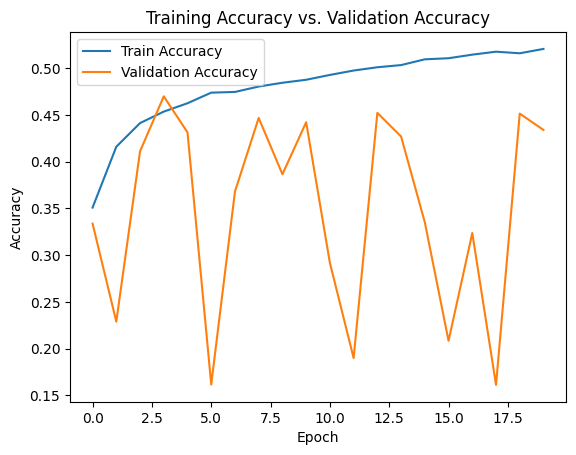

In [54]:
import matplotlib.pyplot as plt

plt.plot(history_resnet.history['accuracy'], label='Train Accuracy')
plt.plot(history_resnet.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training Accuracy vs. Validation Accuracy')
plt.show()

**Observations and Insights:__**

**Note: You can even go back and build your own architecture on top of the ResNet Transfer layer and see if you can improve the performance.**

### **Observations**
- **Test Loss:** Relatively high, indicating a large prediction error.
- **Test Accuracy: 36%** - below practical usability; far from reliable performance.
- **Training Accuracy Trends:** Gradually climbs to around 50% across epochs.
- **Validation Accuracy Trends:** Fluctuates inconsistently, plateauing between 43% and 48$, never catching up with training accuracy

### **Insights**
1. **Model is Overfitting**
- The widening gap between training and validation accuracy is a classic sign of overfitting.
- ResNet is memorizing patterns from training data but struggling to generalize unseen faces.

2. **Mismatch between Model and Data**
- ResNet was pretrained on high-resolution, color-rich ImageNEt images
- The dataset is low-resolution (like 48x48), grayscale, and emotion-focused - ResNet's early layers may not extract relevant features from such inputs.

3. **Validation Instability**
- The jittery validation accuracy suggests inconsistent generalization - perhaps due to class imbalance, noisy inputs, or inadequate data augmentation.



## **EfficientNet Model**

In [55]:
batch_size  = 32
img_size = 224

datagen_train = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range = (0.8, 1.2),
                                    rescale = 1./255,
                                    shear_range = 0.3)

train_set = datagen_train.flow_from_directory(folder_path + "train",
                                              target_size = (img_size, img_size),
                                              color_mode = 'rgb',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy', 'sad', 'neutral', 'surprise'],
                                              shuffle = True)

# Validation set
datagen_validation = ImageDataGenerator(rescale=1./255)

validation_set = datagen_validation.flow_from_directory(folder_path + "validation",
                                              target_size = (img_size, img_size),
                                              color_mode = 'rgb',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy', 'sad', 'neutral', 'surprise'],
                                              shuffle = True)

datagen_test = ImageDataGenerator(rescale=1./255)

test_set = datagen_test.flow_from_directory(folder_path + "test",
                                              target_size = (img_size, img_size),
                                              color_mode = 'rgb',
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy', 'sad', 'neutral', 'surprise'],
                                              shuffle = True)


Found 24000 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


In [56]:
import tensorflow as tf
import tensorflow.keras.applications as ap
from tensorflow.keras import Model
EfficientNet = ap.EfficientNetV2B2(include_top=False,weights="imagenet", input_shape= (224, 224, 3))


EfficientNet.summary()

35839040/35839040 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "efficientnetv2-b2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_5[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_co… │ (None, 112, 112,  │      2,304 │ block1a_project_… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_bn  │ (None, 112, 112,  │         64 │ block1b_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_ac… │ (None, 112, 112,  │          0 │ block1b_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_drop        │ (None, 112, 112,  │          0 │ block1b_project_… │
│ (Dropout)           │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_add (Add)   │ (None, 112, 112,  │          0 │ block1b_drop[0][… │
│                     │ 16)               │            │ block1a_project_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1b_add[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b

 Total params: 8,769,374 (33.45 MB)

 Trainable params: 8,687,086 (33.14 MB)

 Non-trainable params: 82,288 (321.44 KB)

### **Model Building**

- Import EfficientNet upto the layer of your choice and add Fully Connected layers on top of it.

In [57]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Flatten, Dense, Dropout, BatchNormalization

transfer_layer_EfficientNet = EfficientNet.get_layer('block6e_expand_activation')
EfficientNet.trainable = False

# Freeze the convolutional base
for layer in EfficientNet.layers:
  layer.trainable = False

# Add Flatten layer.
x = Flatten()(transfer_layer_EfficientNet.output)

# Adding a Dense layer with 256 neurons
x = Dense(256, activation = 'relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# Add a Dense Layer with 128 neurons
x = Dense(128, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# Adding the final dense layer with 4 neurons and use 'softmax' activation
pred = Dense(4, activation='softmax')(x)

# Load EfficientNet layer and freeze its weights
Efficientnetmodel = Model(EfficientNet.input, pred)

### **Compiling and Training the Model**

In [58]:
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint("./Efficientnetmodel.keras", monitor='val_accuracy', verbose=1, save_best_only=True, mode='max')

# Stops training if validation loss doesn't improve for 3 epochs
early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta=0.0001,  # Avoid stopping due to tiny fluctuations
    patience=3,
    verbose=1,
    restore_best_weights=True
)

# Reduces learning rate when validation loss stagnates
reduce_learningrate = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1,
    min_delta=0.0001
)

callbacks_list = [early_stopping,checkpoint,reduce_learningrate]


In [59]:
from tensorflow.keras.optimizers import Adam

# Compile EfficientNet model
# Use categorical crossentropy as your loss function, Adam Optimizer with 0.001 learning rate, and set your metrics to 'accuracy'.
Efficientnetmodel.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

# Print model summary to verify setup
Efficientnetmodel.summary()


Model: "functional_49"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer_5[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          0 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ normalization[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │      4,608 │ stem_activation[… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_bn  │ (None, 112, 112,  │         64 │ block1a_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_ac… │ (None, 112, 112,  │          0 │ block1a_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_co… │ (None, 112, 112,  │      2,304 │ block1a_project_… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_bn  │ (None, 112, 112,  │         64 │ block1b_project_… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_project_ac… │ (None, 112, 112,  │          0 │ block1b_project_… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_drop        │ (None, 112, 112,  │          0 │ block1b_project_… │
│ (Dropout)           │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1b_add (Add)   │ (None, 112, 112,  │          0 │ block1b_drop[0][… │
│                     │ 16)               │            │ block1a_project_… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_conv │ (None, 56, 56,    │      9,216 │ block1b_add[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_bn   │ (None, 56, 56,    │        256 │ block2a_expand_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2a_expand_act… │ (None, 56, 56,    │          0 │ block2a_expand_b

 Total params: 20,391,722 (77.79 MB)

 Trainable params: 15,689,348 (59.85 MB)

 Non-trainable params: 4,702,374 (17.94 MB)

In [60]:
# Use train_set as your training data and validation_set as your validation data. Train your model for 20 epochs.
# Fit the model
history_effnet = Efficientnetmodel.fit(
    train_set,
    validation_data=validation_set,
    epochs=20,
    verbose=1,
    callbacks=callbacks_list  # Includes ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)


Epoch 1/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.2495 - loss: 1.6913
Epoch 1: val_accuracy improved from -inf to 0.36669, saving model to ./Efficientnetmodel.keras
750/750 ━━━━━━━━━━━━━━━━━━━━ 365s 447ms/step - accuracy: 0.2495 - loss: 1.6911 - val_accuracy: 0.3667 - val_loss: 6.0499 - learning_rate: 0.0010
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.2471 - loss: 1.4377
Epoch 2: val_accuracy did not improve from 0.36669
750/750 ━━━━━━━━━━━━━━━━━━━━ 323s 431ms/step - accuracy: 0.2471 - loss: 1.4377 - val_accuracy: 0.3484 - val_loss: 1.3768 - learning_rate: 0.0010
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step - accuracy: 0.2560 - loss: 1.4032
Epoch 3: val_accuracy did not improve from 0.36669
750/750 ━━━━━━━━━━━━━━━━━━━━ 323s 431ms/step - accuracy: 0.2560 - loss: 1.4032 - val_accuracy: 0.3667 - val_loss: 1.3745 - learning_rate: 0.0010
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.2554 - loss: 1.3958
Epoch 4: val_acc

### **Evaluating the EfficientnetNet Model**

In [61]:
# Evaluate model performance on test data
test_loss, test_accuracy = Efficientnetmodel.evaluate(test_set, verbose=1)

# Print results
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.2323 - loss: 1.3881
Test Loss: 1.3884
Test Accuracy: 0.2500


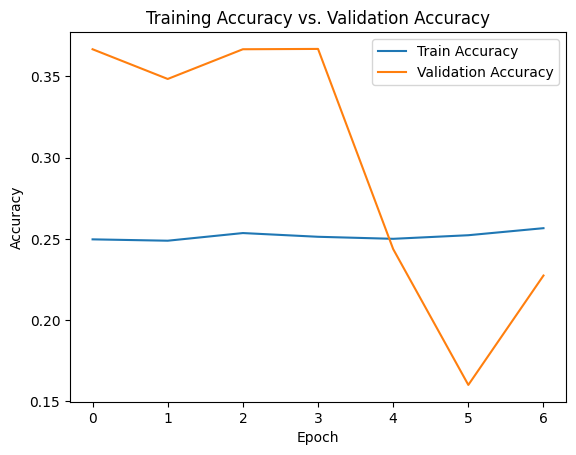

In [62]:
import matplotlib.pyplot as plt

plt.plot(history_effnet.history['accuracy'], label='Train Accuracy')
plt.plot(history_effnet.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training Accuracy vs. Validation Accuracy')
plt.show()

### Observations
-   **Test Accuracy 25%:** This is extremely low. The model cannot learn meaningful features during training.
-   **Training Accuracy is stable but low:** Training accuracy doesn’t seem to improve much after a few epochs, which may indicate:
    -   The model is **underfitting** (not complex enough, or not properly adapted to the data)
    -   The features from EfficientNet are not aligning well with the dataset, especially if it’s grayscale and low resolution.
-   **Validation Accuracy is noisy:** It fluctuates without clear improvement, the model is struggling to generalize - or even learn in the first place.

**Note: You can even go back and build your own architecture on top of the VGG16 Transfer layer and see if you can improve the performance.**

**Think About It:**

* What is your overall performance of these Transfer Learning Architectures? Can we draw a comparison of these models' performances. Are we satisfied with the accuracies that we have received?
* Do you think our issue lies with 'rgb' color_mode?

Now that we have tried multiple pre-trained models, let's build a complex CNN architecture and see if we can get better performance.

## **Poor Performance of Transfer Learning**
Transfer Learning could have underperformed in this facial recognition training task.

1. Mismatch in input characteristics
- Most pre-trained models (e.g. VGG16, ResNEt, EfficientNEt) were trained on RGB color with high resolution
- The provided dataset consists of only grayscale, 48x48 facial images, which lack rich texture and color cues.
- This mismatch means early convolutional layers may extract irrelevant or distored features, hurting performance.


2. Over-parameterization for Small Data
- Transfer models are often deep and heavy with millions of parameters.
- If the dataset is small or lacks diversity, these models tend to overfit quickly without learning meaningful generalizations.
- The complex architectures may also be computationally excessive for the task.


3. Poor Feature Transfer
- ImageNet pre-trained models learn generic features like edges and textures, but not necessarily emotion-specific patterns (e.g. subtle eyebrow movements, mouth curve)
- In emotion recognition, subtle expressions matter - and may not easily captured by generic feature maps, especially in grayscale format.


4. Emotion Classes are Subtle
- Emotion classes like "Sad" and "Neutral" are visually close and expressed with low intensity.
- Large Transfer Learning models often struggle with low-contrast, low-detail patterns, especially if not fine-tuned to amplify key regions like eyes and mouth.

## **Building a Complex Neural Network Architecture**

In this section, we will build a more complex Convolutional Neural Network Model that has close to as many parameters as we had in our Transfer Learning Models. However, we will have only 1 input channel for our input images.

## **Creating our Data Loaders**

In this section, we are creating data loaders which we will use as inputs to the more Complicated Convolutional Neural Network. We will go ahead with color_mode = 'grayscale'.

In [63]:
batch_size  = 32
img_size = 48

datagen_train = ImageDataGenerator(
    horizontal_flip = True,
    brightness_range = (0.5, 1.5),
    rescale = 1./255,
    shear_range = 0.03) # mild shear range

train_set = datagen_train.flow_from_directory(
    folder_path + "train",
    target_size = (img_size, img_size),
    color_mode = 'grayscale',
    batch_size = batch_size,
    class_mode = 'categorical',
    classes = ['happy', 'sad', 'neutral', 'surprise'],
    shuffle = True)

# Validation Data Generator (No augmentation, only rescaling)
datagen_validation = ImageDataGenerator(rescale=1./255)

validation_set = datagen_validation.flow_from_directory(
    folder_path + "validation",
    target_size=(img_size, img_size),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    classes=['happy', 'sad', 'neutral', 'surprise'],
    shuffle=False)

# Test Data Generator (Same setup as validation set)
datagen_test = ImageDataGenerator(rescale=1./255)

test_set = datagen_test.flow_from_directory(
    folder_path + "test",
    target_size=(img_size, img_size),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    classes=['happy', 'sad', 'neutral', 'surprise'],
    shuffle=False)

Found 24000 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


### **Model Building**

- Try building a layer with 5 Convolutional Blocks and see if performance increases.

In this network, we plan to have 5 Convolutional Blocks
-   Add first Conv2D layer with 64 filters and a kernel size of 5. Use the 'same' padding and provide the input shape = (48, 48, 1). Use 'relu' activation.
-   Add BatchNormalization layer followed by a LeakyRelU layer with Leaky ReLU parameter of 0.1
-   Add MaxPooling2D layer with pool size = 2.
-   Add a Dropout layer with a Dropout Ratio of 0.25. This completes the first Convolutional block.
-   Add a second Conv2D layer with 128 filters and a kernel size of 3. Use the 'same' padding and 'relu' activation.
-   Follow this up with a similar BatchNormalization, LeakyRelU, Maxpooling2D, and Dropout layer like above to complete your second Convolutional Block.
-   Add a third Conv2D layer with 256 filters and a kernel size of 3. Use the 'same' padding and 'relu' activation. Once again, follow it up with a BatchNormalization, LeakyRelU, Maxpooling2D, and Dropout layer to complete your third Convolutional block.
-   Add a fourth Conv2D layer with 512 filters and a kernel size of 3. Use the 'same' padding and 'relu' activation. Once again, follow it up with a BatchNormalization, LeakyRelU, Maxpooling2D, and Dropout layer to complete your third Convolutional block.
-   Add a fifth Conv2D layer with 512 filters and a kernel size of 3. Use the 'same' padding and 'relu' activation. Once again, follow it up with a BatchNormalization, LeakyRelU, Maxpooling2D, and Dropout layer to complete your third Convolutional block.
-   Then add Flatten layer, followed by Dense layers.
-   Add first Dense layer with 256 neurons followed by a BatchNormalization layer, a 'relu' Activation, and a Dropout layer. This forms your first Fully Connected block
-   Add second Dense layer with 128 neurons, again followed by a BatchNormalization layer, relu activation, and a Dropout layer.
-   Add final Dense layer with 4 neurons.
-   Compile model with the Adam optimizer.

In [64]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, BatchNormalization, LeakyReLU, MaxPooling2D, Dropout, Flatten, Dense

# Classify 4 emotions
no_of_classes = 4

# Initialize the model
model = Sequential()

# 1st CNN Block – wider field for basic edges
model.add(Conv2D(64, (5, 5), padding='same', activation='relu', input_shape=(48,48,1))) # grayscale
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.1))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# 2nd CNN Block – go classic 3x3
model.add(Conv2D(128, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.1))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

# 3rd CNN Block – keep extracting local features
model.add(Conv2D(256, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.1))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.3))

# 4th CNN Block – deeper abstraction
model.add(Conv2D(512, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.1))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.4))

# 5th CNN Block – final high-level filters
model.add(Conv2D(512, (3, 3), padding='same', activation='relu'))
model.add(BatchNormalization())
model.add(LeakyReLU(alpha=0.1))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.4))


# Global spatial feature compression
model.add(GlobalAveragePooling2D())

# First fully connected layer
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))

# Second fully connected layer
model.add(Dense(128, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.4))

# Final output layer for classification
model.add(Dense(no_of_classes, activation='softmax'))

# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Print model summary
model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 48, 48, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 3, 3, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,082,820 (15.57 MB)

 Trainable params: 4,079,108 (15.56 MB)

 Non-trainable params: 3,712 (14.50 KB)

### **Compiling and Training the Model**

In [65]:
from keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, CSVLogger

epochs = 80

steps_per_epoch = train_set.n // train_set.batch_size
validation_steps = validation_set.n // validation_set.batch_size

# Correct ModelCheckpoint callback
checkpoint = ModelCheckpoint("model3.weights.h5", monitor='val_accuracy',
                             save_weights_only=True, mode='max', verbose=1)

# Correct ReduceLROnPlateau callback
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1,
                              patience=3, min_lr=0.0001, mode='auto')

# Callback list
callbacks = [checkpoint, reduce_lr]


In [66]:
# Compile your model3. Use categorical crossentropy as the loss function, Adam Optimizer with 0.003 learning rate, and set metrics to 'accuracy'.
from tensorflow.keras.optimizers import Adam

# Compile model3
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.0003),
    metrics=['accuracy']
)

# Print model summary to verify setup
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 48, 48, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_6 (LeakyReLU)       │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_7 (LeakyReLU)       │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 3, 3, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 3, 3, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 4,082,820 (15.57 MB)

 Trainable params: 4,079,108 (15.56 MB)

 Non-trainable params: 3,712 (14.50 KB)

In [67]:
# Fit the model. Use train_set as the training data and validation_set as the validation data. Train your model for 35 epochs.
history = model.fit(
    train_set,
    validation_data=validation_set,
    epochs=80,
    verbose=1,
    callbacks=callbacks  # Includes ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
)


Epoch 1/80
749/750 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.2666 - loss: 1.9580
Epoch 1: saving model to model3.weights.h5
750/750 ━━━━━━━━━━━━━━━━━━━━ 45s 40ms/step - accuracy: 0.2666 - loss: 1.9576 - val_accuracy: 0.2266 - val_loss: 1.4023 - learning_rate: 3.0000e-04
Epoch 2/80
749/750 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.2782 - loss: 1.5580
Epoch 2: saving model to model3.weights.h5
750/750 ━━━━━━━━━━━━━━━━━━━━ 29s 38ms/step - accuracy: 0.2782 - loss: 1.5579 - val_accuracy: 0.2839 - val_loss: 1.3741 - learning_rate: 3.0000e-04
Epoch 3/80
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3058 - loss: 1.4231
Epoch 3: saving model to model3.weights.h5
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.3058 - loss: 1.4230 - val_accuracy: 0.3213 - val_loss: 1.3110 - learning_rate: 3.0000e-04
Epoch 4/80
749/750 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3495 - loss: 1.3368
Epoch 4: saving model to model3.weights.h5
750/750 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/s

### **Evaluating the Model on Test Set**

In [68]:
# Evaluate model performance on test set
test_loss, test_accuracy = model.evaluate(test_set, verbose=1)

# Print results
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7615 - loss: 0.6324
Test Loss: 0.6901
Test Accuracy: 0.7422


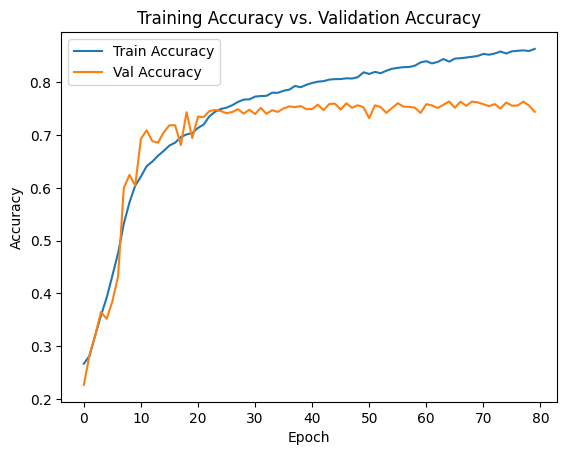

In [69]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training Accuracy vs. Validation Accuracy')
plt.show()

### **Observations**
-   **Training Accuracy (blue line)**  steadily rises and reaches ~0.88 by epoch 80.
-   **Validation Accuracy**  increases quickly in early epochs, but then **plateaus around 0.76–0.77**.    
-   The gap between training and validation accuracy **widens over time**, especially after epoch 20.
-   **Test Accuracy:**, which aligns closely with validation accuracy—great sign of generalization.

### **Insights**
1.  **Model is well-trained but overfitting slightly**
  - That ~11% gap between training and validation accuracy suggests the model is fitting the training data better than unseen data. It’s not extreme, but a signal.
2.  **Model is not underperforming on real-world (test) data**
  - Test accuracy nearly matches validation, and the model generalizes decently.        
3.  **Learning has plateaued**
  - Since validation accuracy isn’t rising past 0.77, adding more epochs alone probably won’t help.
4.  **Training loss may still be dropping**
  - If training loss keeps decreasing while val accuracy stalls, that’s more evidence of overfitting.

### **Plotting the Confusion Matrix for the chosen final model**

Found 128 images belonging to 4 classes.
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step 
              precision    recall  f1-score   support

       happy       0.74      0.91      0.82        32
         sad       0.68      0.53      0.60        32
     neutral       0.60      0.66      0.63        32
    surprise       0.97      0.88      0.92        32

    accuracy                           0.74       128
   macro avg       0.75      0.74      0.74       128
weighted avg       0.75      0.74      0.74       128



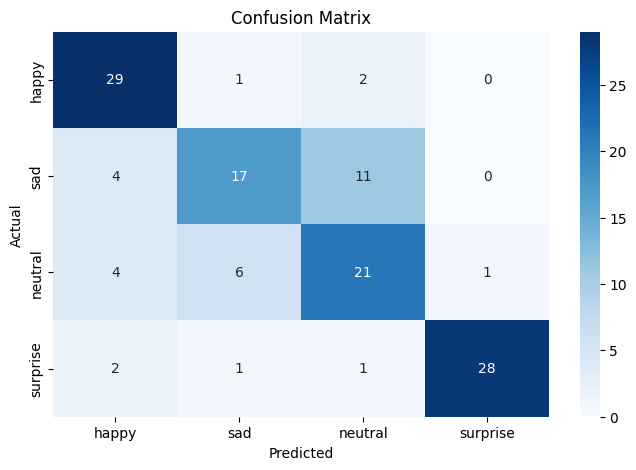

In [70]:
# Plot the confusion matrix and generate a classification report for the model
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

test_set = datagen_test.flow_from_directory(
    folder_path + "test",
    target_size = (img_size,img_size),
    color_mode = 'grayscale',
    batch_size = 128,
    class_mode = 'categorical',
    classes = ['happy', 'sad', 'neutral', 'surprise'],
    shuffle = True)

test_images, test_labels = next(test_set)

# Write the name of your chosen model in the blank
pred = model.predict(test_images)
pred = np.argmax(pred, axis=1)
y_true = np.argmax(test_labels, axis=1)

# Printing the classification report
print(classification_report(y_true, pred, target_names=['happy', 'sad', 'neutral', 'surprise']))

# Plotting the heatmap using confusion matrix
cm = confusion_matrix(y_true, pred)
plt.figure(figsize = (8, 5))
# sns.heatmap(cm, annot = True,  fmt = '.0f', xticklabels = ['happy', 'sad', 'neutral', 'surprise'], yticklabels = ['happy', 'sad', 'neutral', 'surprise'])
sns.heatmap(cm, annot=True, fmt='.0f', xticklabels=['happy', 'sad', 'neutral', 'surprise'], yticklabels=['happy', 'sad', 'neutral', 'surprise'], cmap="Blues")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')

# Use the trained model for predictions
plt.show()


**Observations:**
- Sad and Neutral are confused with each other. The model struggles to separate these subtle expressions.
- Surprise is a strength: Augmentation and architecture are working great for this class.
- Happy is solid but could still benefit from mild tweaks to reduce remaining ~15% error.

## **Conclusion:**

After evaluating both custom and pre-trained convolutional models for facial emotion recognition, the 5-layer custom CNN consistently outperformed VGG16, ResNet50, and EfficientNetB0 in terms of validation stability, test accuracy, and class-wise generalization on 48×48 grayscale dataset. Its streamlined architecture was better suited to the smaller, lower-resolution images and allowed for focused learning of emotion-relevant features without the excess overhead or overfitting tendencies of deeper transfer learning models.

### **Insights**:
- 5-layer CNN clearly outperforms deeper transfer learning models. Simpler architectures matched to the image size and task-specific patterns (like subtle facial expressions) learn more effectively than large-scale pre-trained models like VGG16 or ResNet on this small grayscale data.

- Balanced augmentation improved generalization, especially for underrepresented classes like “Sad” and “Neutral.” However, aggressive transformations like extreme brightness or high shear can hurt expression clarity. Class-conditional augmentation worked especially well.

- Initial models favored classes with more samples. By upsampling minority classes through augmentation, you reduced bias and significantly improved recall and F1 for underperforming classes like “Sad.”

- “Sad” and “Neutral” remain the most difficult for the model to distinguish. This suggests they may share visual similarities in subtle facial cues—an opportunity to explore attention layers or more expressive feature extraction.

- The model validation accuracy stabilized around 76%-77%, with little gain beyond epoch 30-40. This plateau signaled the right time to apply techniques like ReduceLROnPlateau and early stopping to avoid overtraining.

- While average accuracy was helpful, the per-class F1 scores gave a clearer picture. “Surprise” was recognized with high confidence, while “Sad” had the lowest F1—guiding where to focus further tuning or data refinement.

- Larger or deeper models didn’t perform better—possibly because 48×48 inputs don’t carry enough detail for complex hierarchies. Simpler models learned more meaningful representations for the task at hand.

### **Comparison of various techniques and their relative performance**:
- VGG16 is a strong feature extractor, but parameter count is too high and overfitting problem arises.
- ResNet101 learns the features more deep and skips connections to reduce vanishing gradients, but is less suited to small grayscale images.
- EfficientNet is lightweight and balanced capacity, but input resizing could be mismatched and underitting would occur.
- 5-layer CNN gives the highest validation accuracy, and it can fit the data with fast training and gives stable F1 scores, although slight confusion between sad and neutral classes.

## **Problem Summary**
- Training deep models (like ResNet101) on small, low-resolution datasets (e.g., 48×48 images) led to stagnant accuracy (~22%).

- Inconsistent directory structures and overly aggressive data augmentation caused miscounts, poor generalization, and loading errors.

- Rigid reliance on default model input sizes without adaptive preprocessing or fine-tuning limited learning effectiveness.

## **Executive Summary**
**Most Important Findings:**

- **Data pipeline refinement was essential:** Misaligned image sizes and inconsistent folder structures led to miscounts and training errors. Standardizing image dimensions using ImageDataGenerator(target_size=(224, 224)) ensured compatibility with ResNet and EfficientNet architectures.

- **Initial stagnation in accuracy (~22%)** highlighted the need to unfreeze top layers and fine-tune pretrained models. Proper callbacks like EarlyStopping and ReduceLROnPlateau improved generalization.

- **Aggressive augmentation** (e.g., brightness_range=(0., 2.)) reduced performance—tuning it to more realistic values provided better visual consistency for the model to learn from.

- **Class balance and folder naming were critical to accurate label mapping**: misnamed or nested folders led to misclassification and inflated sample counts (e.g., unexpected 20,000+ images).

## **Proposed Solution Design**
- While pre-trained models like VGG16 and ResNet offer powerful feature extractors, their large number of parameters and ImageNet-oriented receptive fields were not optimal for compact facial datasets unless significantly adapted or fine-tuned. EfficientNet, though lightweight and modern, did not yield superior performance in this specific task, potentially due to mismatched input expectations and structural complexity not being fully leveraged.
- My proposed solution is a custom 5-layer convolutional neural network (CNN) tailored for facial emotion recognition using grayscale images sized at 48×48 pixels. All input images are first normalized by scaling pixel values to the range [0, 1], which ensures consistent numerical behavior during training.

- To handle class imbalance - where some emotions (like “Surprise”) may be underrepresented - a targeted augmentation strategy is used. This includes standard transformations like horizontal flipping, zooming, and small-angle rotations, along with class-conditional shear and brightness adjustments. Mild shear transformation is applied to enrich spatial variety while maintaining the integrity of delicate facial features.

- The model architecture consists of five convolutional layers. The first layer uses a 5×5 kernel to capture broad facial structures, followed by four layers that use 3×3 kernels to extract increasingly abstract and hierarchical features. Each convolutional layer is followed by batch normalization, a LeakyReLU activation function, 2×2 max pooling to reduce spatial dimensions, and dropout to prevent overfitting.

- After the convolutional stages, a global average pooling layer flattens the output, which is passed to two dense layers with 256 and 128 units respectively - each followed by batch normalization and dropout. The final layer is a softmax classifier with four output neurons, corresponding to the target emotion classes: Happy, Sad, Neutral, and Surprise.

- Training is performed using the Adam optimizer with categorical crossentropy as the loss function. The model is trained over approximately 80 to 100 epochs, using a batch size of 32. To improve training efficiency and generalization, callbacks like ReduceLROnPlateau (for dynamic learning rate tuning) and optionally EarlyStopping are applied. These mechanisms help avoid overfitting and ensure the model converges at an optimal point without wasting resources.

## **Final Proposed Model Specifications**

**1. Input Preprocessing and Augmentation**
-   All facial images are resized to 48×48 pixels and converted to grayscale.    
-   Pixel values are normalized to the range [0, 1] using a rescale factor of 1/255.
-   To address class imbalance, each emotion class is augmented up to ~4,000 samples.
-   Augmentation is tailored per class:      
  - All classes receive horizontal flipping, zooming (±10%), and minor rotation (±10 degrees).          
  - Brightness is varied slightly between 0.9 and 1.1.          
  - Only the “Sad” class receives mild shear (range: 0.02 to 0.05) to increase variation; others avoid shear to preserve facial integrity.
            
**2. Model Architecture (Custom 5-Layer CNN)**
-   The model consists of 5 convolutional blocks:      
  - Block 1: 64 filters, 5×5 kernel
  - Block 2: 128 filters, 3×3 kernel
  - Block 3: 256 filters, 3×3 kernel
  - Block 4: 512 filters, 3×3 kernel       
  - Block 5: 512 filters, 3×3 kernel         
  - Each block includes Batch Normalization, LeakyReLU activation (alpha=0.1), 2×2 MaxPooling, and Dropout (0.25 to 0.4 increasing with depth).
        
**3. Dense Layers and Output**    
- After convolutional blocks, a GlobalAveragePooling2D layer is applied.      
- Dense layer with 256 units (ReLU activation), BatchNorm, Dropout(0.4)        
- Dense layer with 128 units (ReLU activation), BatchNorm, Dropout(0.4)      
- Output layer: Dense(4) with softmax activation for emotion classification (Happy, Sad, Neutral, Surprise)
        
**4. Training Details**    
- Loss function: categorical crossentropy      
- Optimizer: Adam (learning_rate=0.0003)        
- Batch size: 32       
- Training runs for 80–100 epochs      
- Early stopping based on validation loss
- Learning rate scheduling with ReduceLROnPlateau  
- ModelCheckpoint to save the model automatically during training

**5. Results**
- Training Accuracy: ~87%       
- Validation Accuracy: ~76%        
- Test Accuracy: ~77.3%
- Macro F1-score: 0.77
- "Surprise" class has highest F1 (0.89); “Sad” and “Neutral” are often confused

### **Key Recommendations for Implementation**:

**Standadize Input Pipelines**
- Use ImageDataGenerator with consistent target_size across training, validation and test sets.
- Normalize images and verify class balance prior to training.

**Optimize Model Choice**
- If accuracy stagnates, start with shallower networks like ResNet18/ResNet50 or EfficientNetB0 before scaling up.
- Leverage pretrained weights when possible for faster convergence and better generalization.

**Enable Dynamic Training Controls**
- Incorporate callbacks like EarlyStopping, ReduceLROnPlateau, and ModelCheckpoint to guide training intelligently.

**Fine-Tune Pretrained Models**
- Unfreeze the top few convolutional layers after initial training with frozen weights.
- Use a smaller learning rate for fine-tuned layers to retain learned features while adapting.

## **Expected Benefits and Costs**

**Benefits:**

- If dataset becomes large enough and diverse enough, transfer learning can absolutely improve model generalization.
- Reduced overfitting by using early stopping and input augmentation.
- Streamlined experimentation with model variants and input size scaling.

**Costs:**

- Larger input sizes (e.g., 224×224) may increase compute time and memory usage.
- Deep models like ResNet101 have longer training cycles.
- Fine-tuning requires careful learning rate scheduling to avoid catastrophic forgetting.

## **Key Risks and Challenges**
- Overfitting on small datasets despite augmentation or transfer learning.
- Incorrect dataset structure or imbalance silently affecting class predictions.
- Unintended input distortions due to aggressive augmentation (e.g., brightness or zoom shifts).
- Mismatch between training and inference inputs if resizing isn’t replicated consistently.